In [1]:
import sys
import os
from pathlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Setup path resolution to include project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.visualization import plot_one_dp

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator

In [2]:
npz_path = ['data/test_data/HanSeg_MRI.npz'] 
print(f"Loading {npz_path}...")
dl = DataLoader_npz(npz_path, val_size=0.0)
dl.train_ids = dl.current_ids = list(dl.dataset.keys())

dg = DataGenerator(dl)
print("DataGenerator initialized.")

Loading ['data/test_data/HanSeg_MRI.npz']...

Loading NPZ dataset(s)…
Loaded 4 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\HanSeg_MRI.npz

Final dataset size: 4 patients.

DataGenerator initialized.


In [3]:
# Feel free to change max_number_labels to test multi-label prompting
max_data_points = 100
ds, offsets = dg.get_data_points(max_data_points=max_data_points, offset=10, max_number_labels=1)

print("\nGenerated dataset:")
print(ds)

Creating new Data Points ...
It took 18 seconds

Generated dataset:
<_TensorSliceDataset element_spec=(TensorSpec(shape=(1, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1, 128, 128, 2), dtype=tf.float32, name=None))>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.840713..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.840713..3.5608082].



--- Sample 1 ---
x shape: (1, 128, 128, 1), y shape: (1, 128, 128, 1), p shape: (1, 128, 128, 2)
x   min/max: -0.8407 / 3.5608  (normalized: False)
p_x min/max: -0.8407 / 3.5608  (normalized: False)
y   is binary: True -> Unique values: [0. 1.]
p_y is binary: True -> Unique values: [0. 1.]


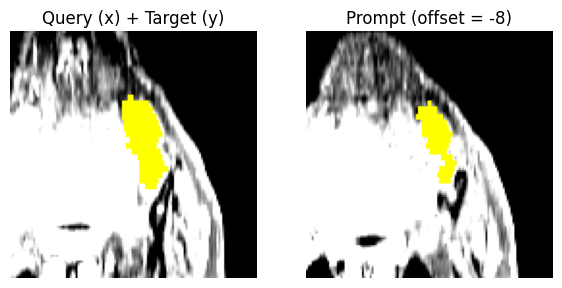

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7947955..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.804635..3.5608082].




--- Sample 2 ---
x shape: (1, 128, 128, 1), y shape: (1, 128, 128, 1), p shape: (1, 128, 128, 2)
x   min/max: -0.7948 / 3.5608  (normalized: False)
p_x min/max: -0.8046 / 3.5608  (normalized: False)
y   is binary: True -> Unique values: [0. 1.]
p_y is binary: True -> Unique values: [0. 1.]


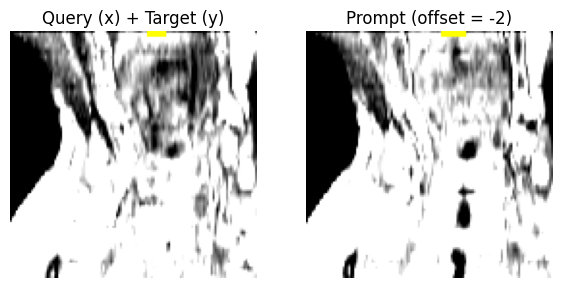

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7619973..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.78167623..3.5608082].




--- Sample 3 ---
x shape: (1, 128, 128, 1), y shape: (1, 128, 128, 1), p shape: (1, 128, 128, 2)
x   min/max: -0.7620 / 3.5608  (normalized: False)
p_x min/max: -0.7817 / 3.5608  (normalized: False)
y   is binary: True -> Unique values: [0. 1.]
p_y is binary: True -> Unique values: [0. 1.]


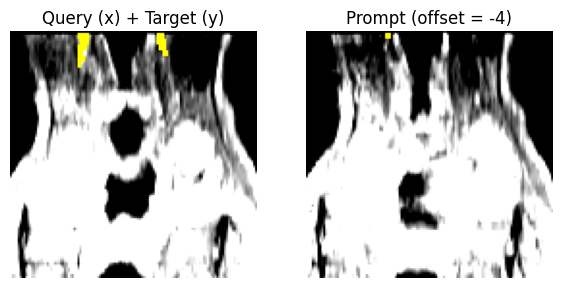

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7882359..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7947955..3.5608082].




--- Sample 4 ---
x shape: (1, 128, 128, 1), y shape: (1, 128, 128, 1), p shape: (1, 128, 128, 2)
x   min/max: -0.7882 / 3.5608  (normalized: False)
p_x min/max: -0.7948 / 3.5608  (normalized: False)
y   is binary: True -> Unique values: [0. 1.]
p_y is binary: True -> Unique values: [0. 1.]


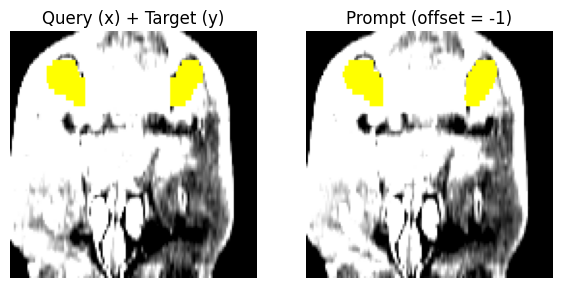

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7423184..3.5608082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7324789..3.5608082].




--- Sample 5 ---
x shape: (1, 128, 128, 1), y shape: (1, 128, 128, 1), p shape: (1, 128, 128, 2)
x   min/max: -0.7423 / 3.5608  (normalized: False)
p_x min/max: -0.7325 / 3.5608  (normalized: False)
y   is binary: True -> Unique values: [0. 1.]
p_y is binary: True -> Unique values: [0. 1.]


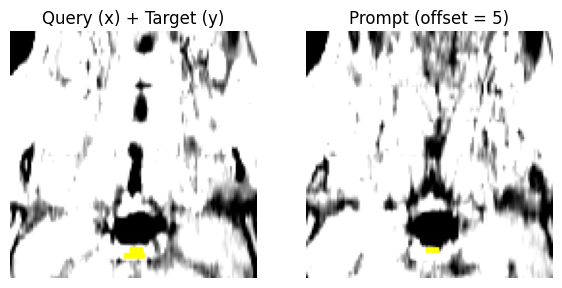

In [6]:
# Take a few samples and plot them
num_samples = 5

for i, (x, y, p) in enumerate(ds.take(num_samples)):
    x_img = x.numpy()
    y_mask = y.numpy()
    
    # Prompt is concatenated [p_x, p_y] on the channel axis
    # If max_number_labels=1, then x_img is 1 channel, and mask is 1 channel. 
    # BUT if x_img was already multi-channel, p_x covers all channels up to the last one.
    p_img = p[..., :-1].numpy() 
    p_mask = p[..., -1:].numpy()

    # -------- VERIFICATION CHECKS --------
    print(f"\n--- Sample {i+1} ---")
    print(f"x shape: {x_img.shape}, y shape: {y_mask.shape}, p shape: {p.numpy().shape}")
    
    # Normalization check (Should be between 0 and 1)
    x_norm = x_img.min() >= 0.0 and x_img.max() <= 1.0
    px_norm = p_img.min() >= 0.0 and p_img.max() <= 1.0
    print(f"x   min/max: {x_img.min():.4f} / {x_img.max():.4f}  (normalized: {x_norm})")
    print(f"p_x min/max: {p_img.min():.4f} / {p_img.max():.4f}  (normalized: {px_norm})")
    
    # Binary check (unique values should be only 0 and 1)
    y_unique = np.unique(y_mask)
    py_unique = np.unique(p_mask)
    y_binary = set(y_unique).issubset({0.0, 1.0})
    py_binary = set(py_unique).issubset({0.0, 1.0})
    print(f"y   is binary: {y_binary} -> Unique values: {y_unique}")
    print(f"p_y is binary: {py_binary} -> Unique values: {py_unique}")
    
    # -------- PLOTTING --------
    plot_one_dp(x,y,p,offsets[i])